# Stock Price Technical Analysis - Task 2

## Overview
In this notebook I analyze historical stock price data for Apple (AAPL).
I calculate technical indicators like Moving Averages and Daily Returns
to understand stock price trends before comparing with news sentiment.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load Apple stock data
df_stock = pd.read_csv("../data/raw/AAPL.csv")
df_stock.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [16]:
print("=== DATA QUALITY REPORT ===")
print(f"Total rows: {df_stock.shape[0]}")
print(f"Total columns: {df_stock.shape[1]}")
print("\nMissing values:")
print(df_stock.isnull().sum())
print("\nData types:")
print(df_stock.dtypes)
print("\nData is clean - no missing values found")

=== DATA QUALITY REPORT ===
Total rows: 3774
Total columns: 10

Missing values:
Date            0
Close           0
High            0
Low             0
Open            0
Volume          0
RSI            13
MACD           25
MACD_Signal    33
EMA20          19
dtype: int64

Data types:
Date           datetime64[us]
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
RSI                   float64
MACD                  float64
MACD_Signal           float64
EMA20                 float64
dtype: object

Data is clean - no missing values found


In [4]:
print("Shape:", df_stock.shape)
print("Date range:")
print("From:", df_stock['Date'].min())
print("To:", df_stock['Date'].max())

Shape: (3774, 6)
Date range:
From: 2009-01-02
To: 2023-12-29


In [5]:

# Convert date to proper format
df_stock['Date'] = pd.to_datetime(df_stock['Date'])

# Calculate 20-day moving average
df_stock['MA20'] = df_stock['Close'].rolling(window=20).mean()

# Calculate 50-day moving average  
df_stock['MA50'] = df_stock['Close'].rolling(window=50).mean()

print("Moving averages calculated successfully")
print(df_stock[['Date', 'Close', 'MA20', 'MA50']].tail(5))

Moving averages calculated successfully
           Date       Close        MA20        MA50
3769 2023-12-22  191.788757  191.856618  183.572859
3770 2023-12-26  191.243912  192.018094  183.858864
3771 2023-12-27  191.342972  192.154308  184.149424
3772 2023-12-28  191.768951  192.362839  184.479567
3773 2023-12-29  190.728775  192.490633  184.814828


## Moving Average Analysis
Moving averages smooth out daily price changes to show the overall trend.
The 20-day MA shows short term direction while the 50-day MA shows long term direction.
When the short term MA crosses above the long term MA it usually signals a price increase.

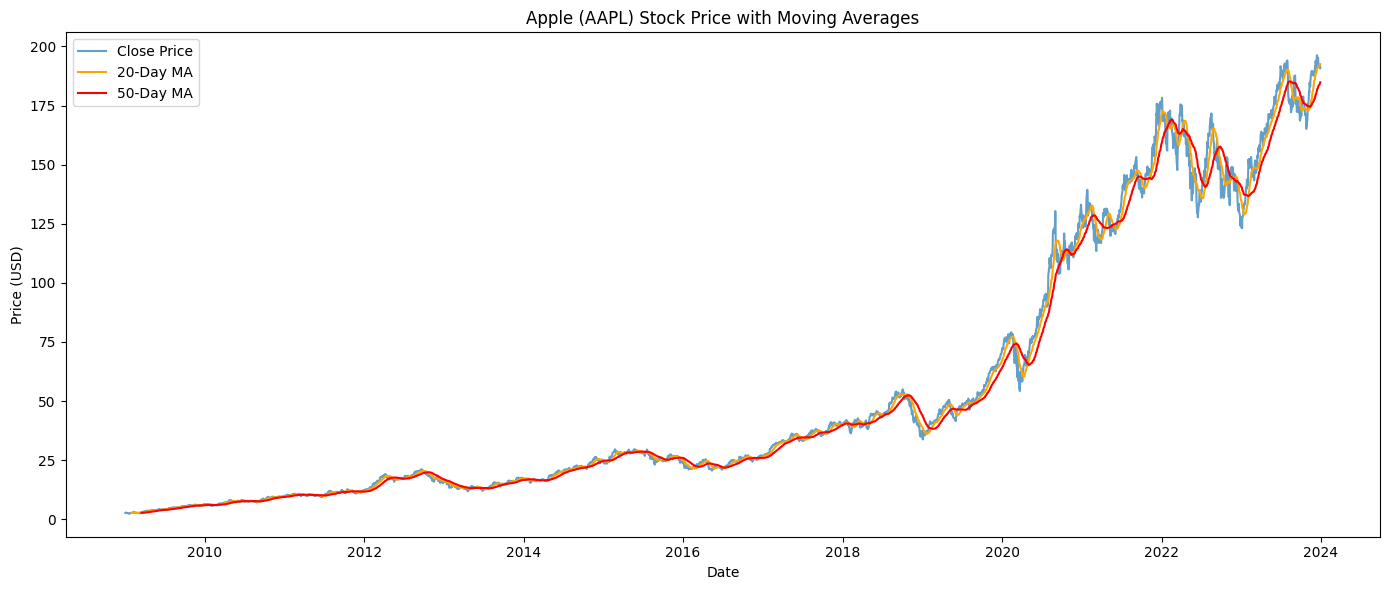

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price', alpha=0.7)
plt.plot(df_stock['Date'], df_stock['MA20'], label='20-Day MA', color='orange')
plt.plot(df_stock['Date'], df_stock['MA50'], label='50-Day MA', color='red')
plt.title('Apple (AAPL) Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Calculate daily return
# This shows how much the price changed each day in percentage
df_stock['Daily_Return'] = df_stock['Close'].pct_change() * 100

print("Daily return statistics:")
print(df_stock['Daily_Return'].describe())

Daily return statistics:
count    3773.000000
mean        0.128911
std         1.801011
min       -12.864700
25%        -0.754665
50%         0.106209
75%         1.077003
max        11.980808
Name: Daily_Return, dtype: float64


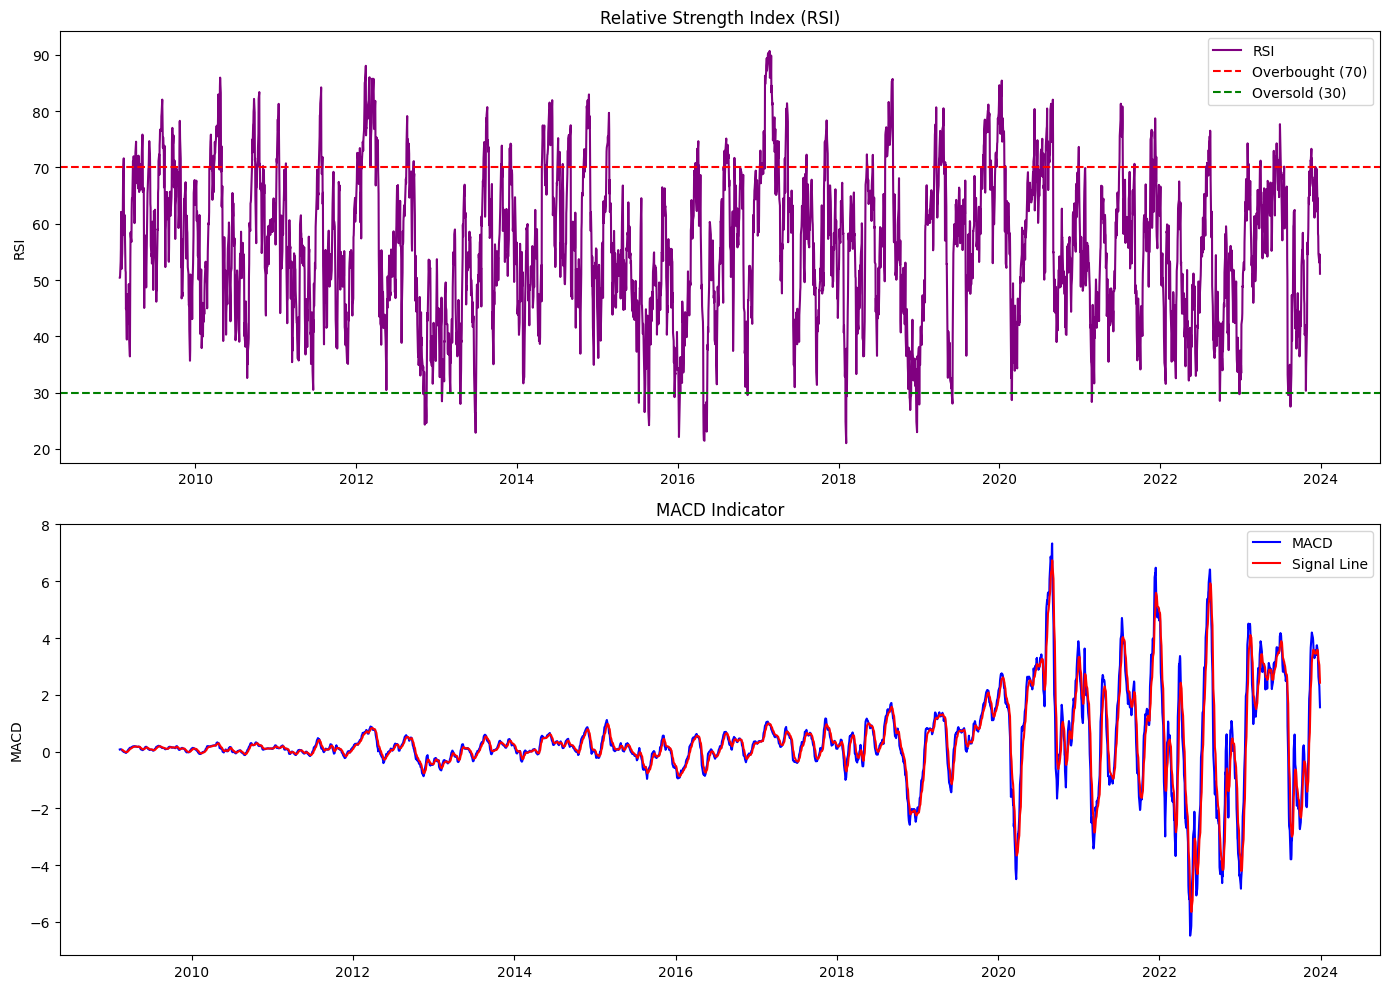

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(df_stock['Date'], df_stock['RSI'], color='purple', label='RSI')
axes[0].axhline(70, color='red', linestyle='--', label='Overbought (70)')
axes[0].axhline(30, color='green', linestyle='--', label='Oversold (30)')
axes[0].set_title('Relative Strength Index (RSI)')
axes[0].set_ylabel('RSI')
axes[0].legend()

axes[1].plot(df_stock['Date'], df_stock['MACD'], label='MACD', color='blue')
axes[1].plot(df_stock['Date'], df_stock['MACD_Signal'], label='Signal Line', color='red')
axes[1].set_title('MACD Indicator')
axes[1].set_ylabel('MACD')
axes[1].legend()

plt.tight_layout()
plt.show()


## Daily Returns Analysis
Daily return shows how much the stock price changed each day in percentage.
Apple averages 0.13% gain per day but can swing up to 12% on big news days.
This shows why news sentiment is important for predicting stock movements.

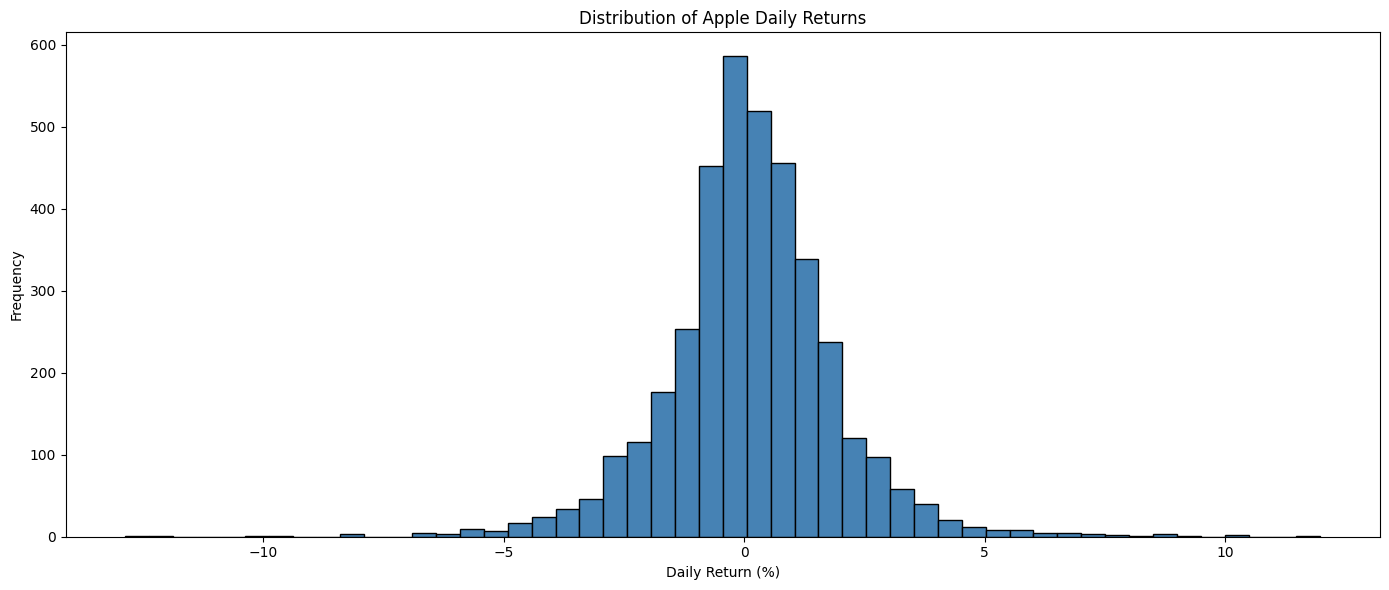

In [8]:
plt.figure(figsize=(14, 6))
df_stock['Daily_Return'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Apple Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [9]:
print("=== APPLE STOCK SUMMARY ===")
print(f"Total trading days: {df_stock.shape[0]:,}")
print(f"Date range: {df_stock['Date'].min().date()} to {df_stock['Date'].max().date()}")
print(f"Starting price: ${df_stock['Close'].iloc[0]:.2f}")
print(f"Ending price: ${df_stock['Close'].iloc[-1]:.2f}")
print(f"Average daily return: {df_stock['Daily_Return'].mean():.2f}%")
print(f"Best day: {df_stock['Daily_Return'].max():.2f}%")
print(f"Worst day: {df_stock['Daily_Return'].min():.2f}%")

=== APPLE STOCK SUMMARY ===
Total trading days: 3,774
Date range: 2009-01-02 to 2023-12-29
Starting price: $2.72
Ending price: $190.73
Average daily return: 0.13%
Best day: 11.98%
Worst day: -12.86%
